In [119]:
# loading the file from the google drive
import pandas as pd
url = 'https://drive.google.com/uc?id=1k4xEnuNFp8J6UYBNxnAi9RWtEg55oKnj'
df = pd.read_csv(url)


In [2]:
# first five rows of the dataset
df.head(5)

,countrycode,countryname,adminzone,adminlevel,date,datatype,indicator name,population,prevalence
0,#country+code,#country+name,#adm1+name,#meta+adminlevel,#date,#data+type,#indicator+name,#population,#indicator+prevalence
1,ZWE,Zimbabwe,NaN,national,1/15/2025,SURVEY,fcs,4501062,0.296532593
2,ZWE,Zimbabwe,NaN,national,1/15/2025,SURVEY,rcsi,8885207,0.585362704
3,ZWE,Zimbabwe,Bulawayo,subnational,1/15/2025,SURVEY,total,665940,NaN
4,ZWE,Zimbabwe,Bulawayo,subnational,1/15/2025,SURVEY,fcs,94628,0.142096886


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6723 entries, 0 to 6722
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   countrycode     6723 non-null   object
 1   countryname     6723 non-null   object
 2   adminone        6721 non-null   object
 3   adminlevel      6723 non-null   object
 4   date            6723 non-null   object
 5   datatype        6723 non-null   object
 6   indicator name  6723 non-null   object
 7   population      6723 non-null   object
 8   prevalence      4513 non-null   object
dtypes: object(9)
memory usage: 472.8+ KB


In [8]:
# check null value is present or not
print(df.isnull().sum())

countrycode          0
countryname          0
adminone             2
adminlevel           0
date                 0
datatype             0
indicator name       0
population           0
prevalence        2210
dtype: int64


In [ ]:
# preprocessing step: create the function preprocessing, which include removing metarow, date conversion, datatype conversions
# fill missing value, normalize column

In [3]:
def data_preprocessing(df):
    df= df.iloc[1:].reset_index(drop=True)# remove the first metarow
    df['date'] = pd.to_datetime(df['date'], errors='coerce') # convert the date into datetime format
    df['population'] = pd.to_numeric(df['population'], errors='coerce')# convert the population column datatype string to numeric
    df['prevalence'] = pd.to_numeric(df['prevalence'], errors='coerce')# convert the prevalence column datatype string to numeric
    df['adminzone'] = df['adminzone'].fillna('Unknown')# fill null value with Unknown
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace(r'[^\w\s]', '', regex=True)# Normalize column names
    df['prevalence'] = df['prevalence'].fillna(df['prevalence'].mean())# fill missing value using mean
    print(df.head(5))
    print(df.isnull().sum())
    df.to_csv(r"C:\Users\dnyan\Desktop\clean data\cleandata.csv",index=False)
data_preprocessing(df)

  countrycode countryname adminzone   adminlevel       date datatype  \
0         ZWE    Zimbabwe   Unknown     national 2025-01-15   SURVEY   
1         ZWE    Zimbabwe   Unknown     national 2025-01-15   SURVEY   
2         ZWE    Zimbabwe  Bulawayo  subnational 2025-01-15   SURVEY   
3         ZWE    Zimbabwe  Bulawayo  subnational 2025-01-15   SURVEY   
4         ZWE    Zimbabwe  Bulawayo  subnational 2025-01-15   SURVEY   

  indicator_name  population  prevalence  
0            fcs     4501062    0.296533  
1           rcsi     8885207    0.585363  
2          total      665940    0.459019  
3            fcs       94628    0.142097  
4           rcsi      295257    0.443369  
countrycode       0
countryname       0
adminzone         0
adminlevel        0
date              0
datatype          0
indicator_name    0
population        0
prevalence        0
dtype: int64


In [1]:
import pandas as pd
import numpy as np


In [2]:
url = 'https://drive.google.com/uc?id=1tuVClS-8C-fvMWHEORAo36WosG_w0-yL'
df = pd.read_csv(url)



In [3]:
df.head()

,countrycode,countryname,adminzone,adminlevel,date,datatype,indicator_name,population,prevalence
0,ZWE,0,0,1,1/15/2025,SURVEY,3,665940,0.459019
1,ZWE,0,0,1,1/15/2025,SURVEY,2,295257,0.443369
2,ZWE,0,1,1,1/15/2025,SURVEY,2,1393744,0.574217
3,ZWE,0,2,1,1/15/2025,SURVEY,3,2037762,0.459019
4,ZWE,0,2,1,1/15/2025,SURVEY,0,586820,0.287973


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

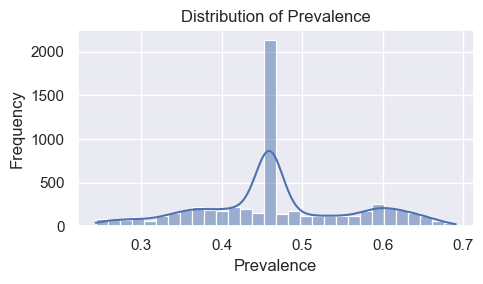

In [5]:
# distribution of prevalence
sns.set(style="darkgrid")
plt.figure(figsize=(5, 3))
sns.histplot(df['prevalence'], bins=30, kde=True)
plt.title('Distribution of Prevalence')
plt.xlabel('Prevalence')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

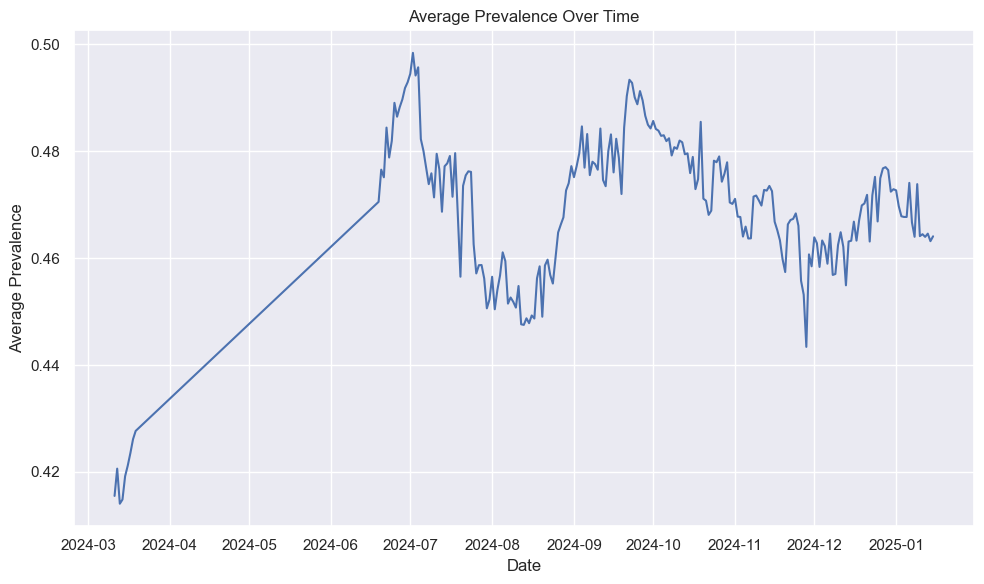

In [6]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df_time = df.groupby('date')['prevalence'].mean().reset_index()
# Plot 2: Prevalence Over Time
plt.figure(figsize=(10,6))
sns.lineplot(data=df_time, x='date', y='prevalence')
plt.title('Average Prevalence Over Time')
plt.xlabel('Date')
plt.ylabel('Average Prevalence')
plt.tight_layout()
plt.show()



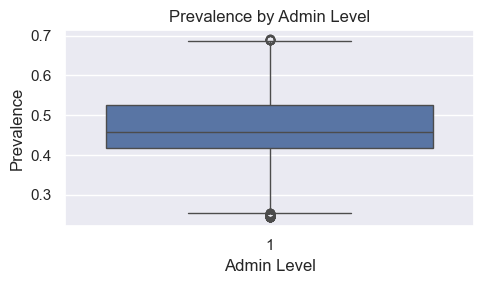

In [7]:
#Plot 3: Prevalence by Admin Level
plt.figure(figsize=(5, 3))
sns.boxplot(x='adminlevel', y='prevalence', data=df)
plt.title('Prevalence by Admin Level')
plt.xlabel('Admin Level')
plt.ylabel('Prevalence')
plt.tight_layout()
plt.show()


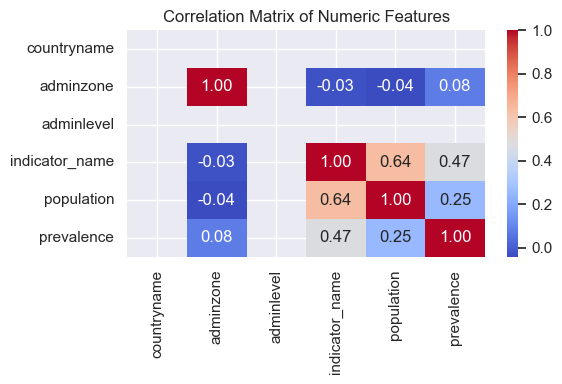

In [8]:
# Plot 4: Correlation Heatmap
plt.figure(figsize=(6, 4))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()


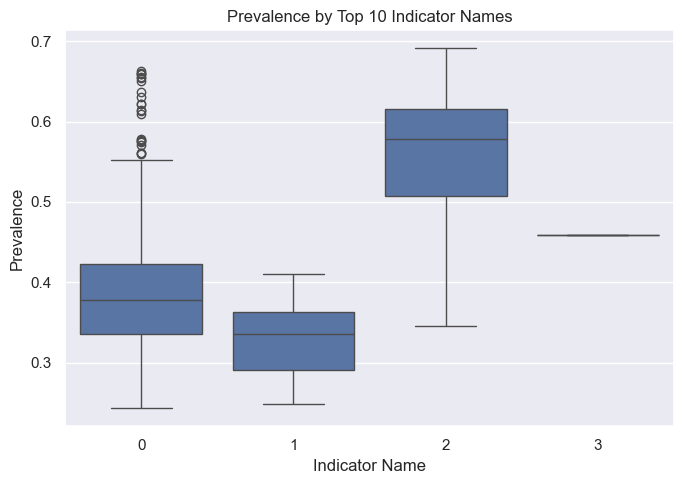

In [9]:
# Plot 5: Prevalence by Top 10 Indicators
top_indicators = df['indicator_name'].value_counts().index[:10]
plt.figure(figsize=(7, 5))
sns.boxplot(x='indicator_name', y='prevalence', data=df[df['indicator_name'].isin(top_indicators)])
plt.title('Prevalence by Top 10 Indicator Names')
plt.xlabel('Indicator Name')
plt.ylabel('Prevalence')
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [5]:
def FeatureEngineering(df):
        df_engineer = df.copy()
    # label-encode
        for col in ['adminzone', 'indicator_name']:
            if col in df.columns:
                df[col] = LabelEncoder().fit_transform(df[col].astype(str))
        # numeric conversions
        df['population'] = pd.to_numeric(df.get('population'), errors='coerce')
        df['adminlevel'] = pd.to_numeric(df.get('adminlevel'), errors='coerce')
        df['adminzone']   = pd.to_numeric(df.get('adminzone'),   errors='coerce')
        # date features
        if 'date' in df.columns:
            df['date']    = pd.to_datetime(df['date'], errors='coerce')
            df['year']    = df['date'].dt.year
            df['month']   = df['date'].dt.month
            df['quarter'] = df['date'].dt.quarter
        # population scaling & log
        if 'population' in df.columns:
            df['population_scaled'] = StandardScaler().fit_transform(df[['population']])
            df['log_population']    = np.log1p(df['population'])
        # one-hot encode if present
        dummy_cols = [c for c in ['countrycode', 'datatype'] if c in df.columns]
        if dummy_cols:
            df = pd.get_dummies(df, columns=dummy_cols, drop_first=True)

        df = df.dropna(subset=['population', 'adminlevel'])
        # interaction features
        df['pop_x_adminlevel'] = df['population'] * df['adminlevel']
        if {'adminzone', 'indicator_name'}.issubset(df.columns):
            df['zone_x_indicator'] = df['adminzone'] * df['indicator_name']
        return df
df_engineer = FeatureEngineering(df)


In [6]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt
import tensorflow as tf
from datetime import timedelta
import random
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [24]:
# Xgboost model

In [13]:
# features and target variable
features_xgb = ['adminzone', 'indicator_name', 'population']
X_xgb = df[features_xgb]
y_xgb = df['prevalence']

# Split the data
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_xgb, y_xgb, test_size=0.2, random_state=42)

# fit the model
model_xgb = XGBRegressor(n_estimators=100,learning_rate=0.05,max_depth=3,reg_alpha=1,reg_lambda=1,subsample=0.7,
                         colsample_bytree=0.7,
                         random_state=42
)
model_xgb.fit(X_train_xgb, y_train_xgb)
# prediction to make
y_pred_xgb = model_xgb.predict(X_test_xgb)
# metrics
mse = mean_squared_error(y_test_xgb, y_pred_xgb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_xgb, y_pred_xgb)
print("XGBoost  Evaluation:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")


XGBoost  Evaluation:
MSE: 0.0012
RMSE: 0.0342
R²: 0.8796


In [14]:
X_test_xgb_copy = X_test_xgb.copy()
X_test_xgb_copy['predicted_prevalence'] = y_pred_xgb
X_test_xgb_copy['actual_prevalence'] = y_test_xgb.values

# set the  crisis threshold 
CRISIS_THRESHOLD = 0.3

crisis_zones = X_test_xgb_copy[X_test_xgb_copy['predicted_prevalence'] >= CRISIS_THRESHOLD]


print("\nIdentified Hunger Hotspots (Predicted prevalence >= 0.3):")
print(crisis_zones[['adminzone', 'indicator_name', 'population', 'predicted_prevalence']])


Identified Hunger Hotspots (Predicted prevalence >= 0.3):
      adminzone  indicator_name  population  predicted_prevalence
5731          8               2      298278              0.485025
3947          8               2      354366              0.523007
4204          0               3      665940              0.453927
5910          5               3     1893578              0.461120
4122          1               0      740415              0.307811
...         ...             ...         ...                   ...
2584          8               3      760345              0.459146
721           7               0      323257              0.438822
2407          6               3     1638539              0.461120
1025          6               2     1107832              0.599905
1616          8               0      290619              0.365061

[1201 rows x 4 columns]


In [33]:
crisis_zones.to_csv(r"C:\Users\dnyan\Desktop\clean data\ 1.csv",index=False)

In [34]:
# Random Forest Regressor Model

In [15]:
# feature selection and target variable
features = ['countryname', 'adminlevel', 'population', 'year', 'month']
X = df[features]
y = df['prevalence']
# spliting for testing and training 
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X, y, test_size=0.2, random_state=42)
# model initialization and training
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train_rf, y_train_rf)
# prediction
y_pred_rf = model_rf.predict(X_test_rf)
# evaluation metrics
mse = mean_squared_error(y_test_rf, y_pred_rf)
r2 = r2_score(y_test_rf, y_pred_rf)
rmse = np.sqrt(mse)
print(" Random Forest Evaluation:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


 Random Forest Evaluation:
Mean Squared Error: 0.0029
R² Score: 0.7008
Root Mean Squared Error (RMSE): 0.0540


In [12]:
X_full = df[features]
y_pred_full = model_rf.predict(X_full)
tmp = df[['countryname', 'adminzone', 'population', 'date']].copy()
tmp['pred_prevalence_rf'] = y_pred_full
# set the  crisis threshold
threshold = 0.30
tmp['crisis'] = tmp['pred_prevalence_rf'] >= threshold
latest = tmp.sort_values('date').groupby(['countryname', 'adminzone'], as_index=False).last()
crisis_zones = latest[latest['crisis']].sort_values('pred_prevalence_rf', ascending=False)
print("Zones flagged as in crisis (Random Forest):")
print(crisis_zones[[ 'adminzone', 'population', 'pred_prevalence_rf', 'date']].head(5))


Zones flagged as in crisis (Random Forest):
   adminzone  population  pred_prevalence_rf       date
7          7      535718            0.646936 2025-01-15
9          9     1122404            0.613103 2025-01-15
1          1     1393744            0.594104 2025-01-15
4          4      941741            0.548921 2025-01-15
6          6     1018332            0.529178 2025-01-15


In [39]:
crisis_zones.to_csv(r"C:\Users\dnyan\Desktop\clean data\ 2.csv",index=False)

In [13]:
# LSTM(Long Short Term Memory)

In [10]:
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)


df['date'] = pd.to_datetime(df['date'])

# filter for Zimbabwe
df_zimbabwe = df[df['countrycode'] == 'ZWE'].copy()
# aggregate the daily data
df_zim = df_zimbabwe.groupby('date').agg({
    'prevalence': 'mean',
    'population': 'sum'
}).reset_index().sort_values('date')

# scale the prevelance and population field using normalization
scaler = MinMaxScaler()
df_zim[['prevalence', 'population']] = scaler.fit_transform(df_zim[['prevalence', 'population']])

# prepare sequences
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len, :])
        y.append(data[i+seq_len, 0]) 
    return np.array(X), np.array(y)

sequence_length = 12
data = df_zim[['prevalence', 'population']].values
X, y = create_sequences(data, sequence_length)

# Split for test and train
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(X.shape[1], X.shape[2])))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=30, batch_size=8, verbose=1)

# predict
y_pred_lstm = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred_lstm)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lstm)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# prediction for next 5 days


future_steps = 5
last_sequence = data[-sequence_length:]
last_date = df_zim['date'].max()

predictions, dates = [], []

for _ in range(future_steps):
    pred = model.predict(last_sequence.reshape(1, sequence_length, 2), verbose=0)[0][0]
    predictions.append(pred)
    last_date += timedelta(days=1)
    dates.append(last_date)
    next_step = np.array([pred, last_sequence[-1, 1]])  # keep population constant
    last_sequence = np.vstack([last_sequence[1:], next_step])

# Inverse transform predictions
prevalence_scaled = np.array(predictions).reshape(-1, 1)
dummy_pop = np.zeros_like(prevalence_scaled)
inv_preds = scaler.inverse_transform(np.hstack([prevalence_scaled, dummy_pop]))[:, 0]

# Print results
print("Top 5 Predicted Hunger Hotspots (Next 5 Days):")
for date, val in zip(dates, inv_preds):
    print(f"Date: {date.date()}, Predicted Prevalence: {val:.4f}")



c:\Users\dnyan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.2943
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0144
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0091
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0067
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0061
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0060
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0059
Epoch 8/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0058
Epoch 9/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0057
Epoch 10/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0056
Epoch 11/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0055
Epoch 12/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0054
Epoch 13/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0053
Epoch 14/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0052
Epoch 15/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0051
Epoch 16/30
21/2

In [36]:
# save the forecast to CSV
forecast_df = pd.DataFrame({
    'date': dates,
    'predicted_prevalence': inv_preds
})

forecast_df.to_csv(r"C:\Users\dnyan\Desktop\clean data\ 3.csv", index=False)


In [40]:
# Linear Regression

In [17]:

df['pop_x_adminlevel'] = df['population'] * df['adminlevel']
df['zone_x_indicator'] = df['adminzone'] * df['indicator_name']

feature_cols = [
    'countryname', 'adminzone', 'adminlevel', 'indicator_name',
    'log_population', 'year', 'month', 'quarter',
    'pop_x_adminlevel', 'zone_x_indicator'
] + [col for col in df.columns if col.startswith('countrycode_') or col.startswith('datatype_')]
#  Drop rows with missing target or features
df_model = df.dropna(subset=feature_cols + ['prevalence'])
#  Define input and target
X = df_model[feature_cols]
y = df_model['prevalence']
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#  Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
#  Train model
model = LinearRegression()
model.fit(X_train, y_train)
# Evaluate on test set
y_pred_lr = model.predict(X_test)
mse_test = mean_squared_error(y_test, y_pred_lr)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_lr)
# Print results
print(" Linear Performance:")
print(f"Test MSE: {mse_test:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")
print(f"Test R²: {r2_test:.4f}")




 Linear Performance:
Test MSE: 0.0058
Test RMSE: 0.0759
Test R²: 0.4078


In [72]:
zone_stats = df.groupby([ 'adminone'], as_index=False)['prevalence'].mean()
top_5_zones = zone_stats.sort_values(by='prevalence', ascending=False).head(5)
print(" Top 5 Zones Most Affected by Hunger Crisis:")
print(top_5_zones[[ 'adminone', 'prevalence']])


 Top 5 Zones Most Affected by Hunger Crisis:
   adminone  prevalence
3         3    0.575816
7         7    0.569393
2         2    0.535577
5         5    0.526780
9         9    0.520494


In [73]:
top_5_zones.to_csv(r"C:\Users\dnyan\Desktop\clean data\ 4.csv",index=False)

In [74]:
#Decision Tree Regressor

In [18]:
# features and target
X = df.drop(columns=['prevalence']).select_dtypes(include=[np.number])
y = pd.to_numeric(df['prevalence'], errors='coerce')
# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# train the Decision Tree Regressor
regressor = DecisionTreeRegressor(max_depth=5, random_state=42)
regressor.fit(X_train, y_train)
# Make predictions
y_pred_dt = regressor.predict(X_test)
# Evaluate the model
mse = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_dt)
# Print evaluation metrics
print(f"Decision Tree evaluation:")
print(f" Mean Squared Error (MSE): {mse:.4f}")
print(f" Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f" R² Score: {r2:.2f}")


Decision Tree evaluation:
 Mean Squared Error (MSE): 0.0013
 Root Mean Squared Error (RMSE): 0.0357
 R² Score: 0.87


In [ ]:
# Hybrid Stacked Model

In [19]:
# ensure all predictions are the same length because of different output length due to preprocessing
# it find the shortest prediction length so all the arrays can be trimmed to match
min_len = min(
    len(y_pred_xgb),
    len(y_pred_rf),
    len(y_pred_lstm),
    len(y_pred_lr),
    len(y_pred_dt),
    len(y_test)
)
# Converts predictions to numpy arrays flattens them to 1D, and trims them to min len.
y_true = y_test[:min_len]
pred_xgb = np.array(y_pred_xgb).flatten()[:min_len]
pred_rf = np.array(y_pred_rf).flatten()[:min_len]
pred_lstm = np.array(y_pred_lstm).flatten()[:min_len]
pred_lr = np.array(y_pred_lr).flatten()[:min_len]
pred_dt = np.array(y_pred_dt).flatten()[:min_len]
#Create the meta-model input
X_meta = np.column_stack([pred_xgb, pred_rf, pred_lstm, pred_lr, pred_dt])
#  Train the meta-model
meta_model = LinearRegression()
meta_model.fit(X_meta, y_true)
# Predict and evaluate
meta_pred = meta_model.predict(X_meta)# final prediction from the stacked model
mse = mean_squared_error(y_true, meta_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, meta_pred)
print("\n Hybrid Model Performance:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")



 Hybrid Model Performance:
MSE: 0.0012
RMSE: 0.0347
R² Score: 0.8508


In [21]:
# set threshold for hunger crisis
hunger_threshold = 0.3 
hunger_crisis_spots = df[df['prevalence'] > hunger_threshold][
    [ 'adminzone', 'adminlevel',  'prevalence']
].sort_values(by='prevalence', ascending=False)

print(" Hunger Crisis Spots (Prevalence > 0.3):")
print(hunger_crisis_spots.head(5)) 


 Hunger Crisis Spots (Prevalence > 0.3):
      adminzone  adminlevel  prevalence
3659          5           1    0.690926
5114          3           1    0.690672
5881          5           1    0.690216
2429          3           1    0.689869
5059          3           1    0.689537


In [93]:
hunger_crisis_spots.to_csv(r"C:\Users\dnyan\Desktop\clean data\ 5.csv",index=False)